<a href="https://colab.research.google.com/github/AlejoCanas/Lenguajes-de-Programaci-n/blob/main/Taller_Portafolio_Estudiantes%20(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Taller Evaluativo (20%) - Análisis de Portafolio
### Curso: Ingeniería Financiera / Programación  
### Herramienta: Google Colab  
---
### 🎯 Objetivo
Este taller busca que comprendas qué es un análisis de portafolio, cómo se calculan y analizan sus métricas (rentabilidad, riesgo y correlación), y cómo se interpreta el resultado para tomar decisiones de inversión.

👉 **Importante:** No basta con ejecutar el código. Debes **completar los espacios en blanco**, responder las **preguntas de investigación** y redactar un **análisis final**.

## 1. Importación de librerías
Primero, importa las librerías necesarias para trabajar con datos financieros.

In [1]:
# COMPLETAR: importa las librerías necesarias (yfinance, pandas, numpy, matplotlib, seaborn)
# Ejemplo: import yfinance as yf

# COMPLETAR AQUÍ

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Descarga de datos
Usa `yfinance` para descargar los precios de **Google (GOOG)**, **Amazon (AMZN)** y **Microsoft (MSFT)** durante los últimos 3 años. Utiliza la columna `Adj Close`.

🔎 **Pregunta:** ¿Por qué es más adecuado usar `Adj Close` que `Close` para un análisis financiero?

## Procedemos a la descarga respectiva:

In [14]:
# COMPLETAR: descarga los precios de las acciones usando yf.download

acciones = ["GOOG", "AMZN", "MSFT"]
datos = yf.download(tickers=acciones, period="3y", auto_adjust=False)["Close"]
print(datos.head())


[*********************100%***********************]  3 of 3 completed

Ticker            AMZN        GOOG        MSFT
Date                                          
2022-09-19  124.660004  103.849998  244.520004
2022-09-20  122.190002  101.830002  242.449997
2022-09-21  118.540001  100.010002  238.949997
2022-09-22  117.309998  100.570000  240.979996
2022-09-23  113.779999   99.169998  237.919998


In [ ]:
datos.tail() # Veo los últimos 5 datos

Ticker,AMZN,GOOG,MSFT
Date,,,
2025-09-10,230.330002,239.559998,500.369995
2025-09-11,229.949997,240.779999,501.010010
2025-09-12,228.149994,241.380005,509.899994
2025-09-15,231.429993,251.759995,515.359985
2025-09-16,234.050003,251.419998,509.040009


## ¿Por qué es más adecuado usar "Adj Close" que "Close" para el análisis financiero?

Es mucho más relevante hacer uso de "Close" y no de "Adj Close" finalmente, debido a que es el precio de cierre de las acciones como factor de cálculo de rendimientos de las mismas. Por otra parte "Adj Close" no se encuentra en las columnas dadas desde YahooFinance.

## 3. Visualización de precios
Grafica en una misma figura la evolución de los precios de cierre ajustados de las tres acciones.

🔎 **Pregunta:** ¿Cuál de las tres acciones muestra mayor crecimiento en estos 3 años?

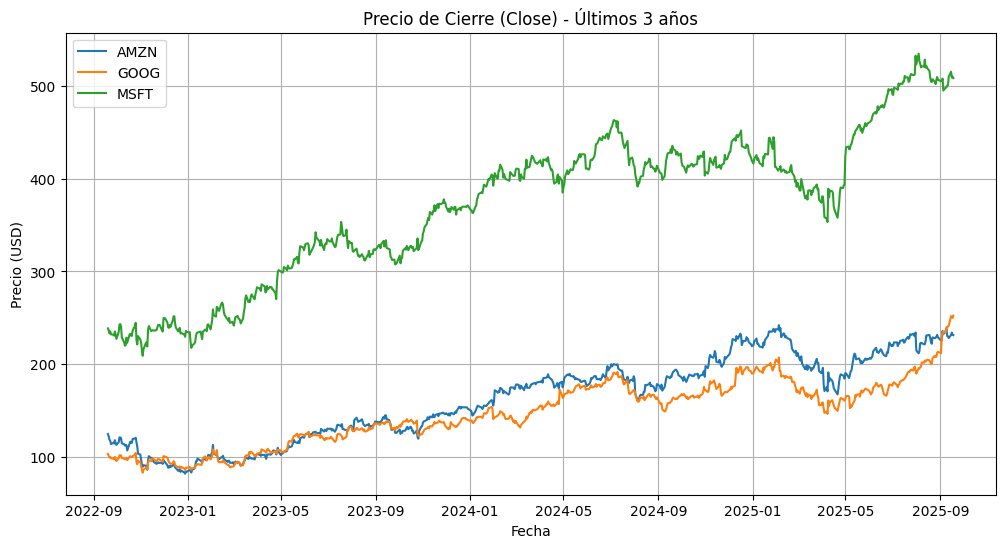

In [10]:
# COMPLETAR: grafica las tres series de precios en una sola gráfica

plt.figure(figsize=(12,6))
for col in datos.columns:
  plt.plot(datos[col], label=col)


plt.title('Precio de Cierre (Close) - Últimos 3 años')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Respuesta al análisis según la pregunta:

Las acciones con mayor incremento como se evidencia en la gráfica de tendencias son las acciones de MICROSOFT "De variable MSFT" las cuales tuvieron un impacto a la suba en los ultimos 3 años desde el estudio realizado, superando las otras dos variables dadas.

## 4. Rentabilidades
Calcula las **rentabilidades logarítmicas diarias** y grafícalas.

🔎 **Pregunta:** ¿Qué diferencias encuentras entre observar precios y observar rentabilidades?

In [11]:
# Rendimientos logarítmicos diarios
rendimientos = np.log(datos / datos.shift(1)).dropna()

# Mostrar
rendimientos.head()

Ticker,AMZN,GOOG,MSFT
Date,,,
2022-09-20,-0.020013,-0.019643,-0.008502
2022-09-21,-0.030327,-0.018035,-0.014541
2022-09-22,-0.010430,0.005584,0.008460
2022-09-23,-0.030553,-0.014019,-0.012779
2022-09-26,0.011969,-0.003637,-0.001977


## Gráfico

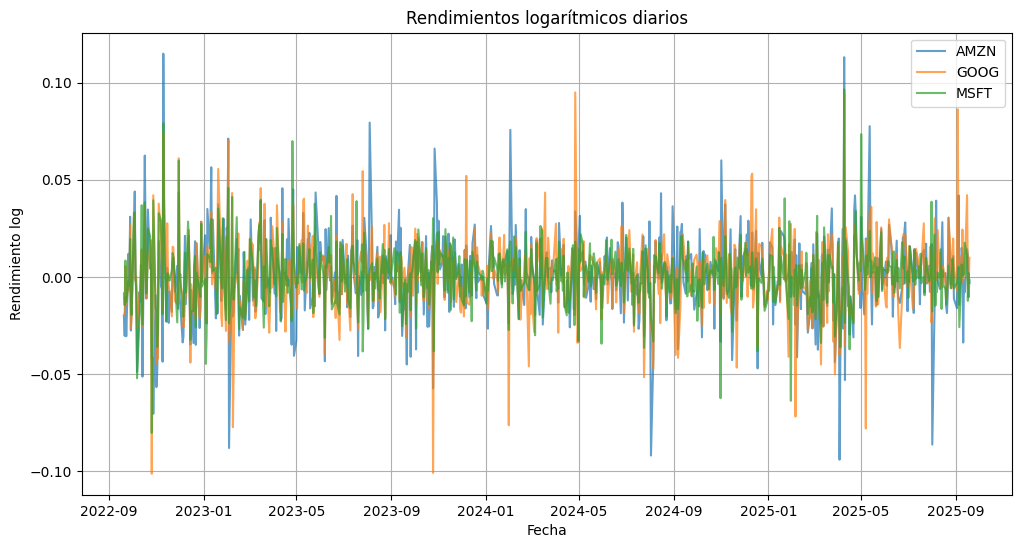

In [13]:
plt.figure(figsize=(12,6))
for col in rendimientos.columns:
  plt.plot(rendimientos.index, rendimientos[col], label=col, alpha=0.7)


plt.title('Rendimientos logarítmicos diarios')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento log')
plt.legend()
plt.grid(True)
plt.show()

## 5. Medidas estadísticas
Calcula la **rentabilidad promedio** y la **volatilidad (desviación estándar)** de cada acción.

🔎 **Pregunta:** ¿Cuál acción es más riesgosa? ¿Cuál ofrece mayor retorno?

In [ ]:
# COMPLETAR: calcula media y desviación estándar

media = # COMPLETAR AQUÍ
volatilidad = # COMPLETAR AQUÍ

print("Rentabilidad promedio diaria:")
print(media)
print("\nVolatilidad diaria:")
print(volatilidad)

## 6. Correlación entre activos
Calcula y grafica la matriz de correlación entre las acciones.

🔎 **Pregunta:** ¿Qué significa que dos acciones tengan una correlación cercana a 1? ¿Y cercana a 0 o negativa?

In [ ]:
# COMPLETAR: calcula la correlación y haz un mapa de calor con seaborn

correlacion = # COMPLETAR AQUÍ
sns.heatmap(correlacion, annot=True, cmap="coolwarm")
plt.show()

## 7. Portafolio simulado
Supón un portafolio con la siguiente distribución:
- 40% Google
- 30% Amazon
- 30% Microsoft

Calcula el **retorno esperado** y la **volatilidad del portafolio**.

🔎 **Preguntas:**
1. ¿Cómo interpretas el retorno esperado del portafolio?
2. ¿Qué efecto tuvo la diversificación sobre la volatilidad respecto a invertir en una sola acción?

In [ ]:
# COMPLETAR: cálculo del retorno y riesgo del portafolio

pesos = np.array([0.4, 0.3, 0.3])

retorno_portafolio = # COMPLETAR AQUÍ
covarianza = # COMPLETAR AQUÍ
vol_portafolio = # COMPLETAR AQUÍ

print("Retorno esperado del portafolio (diario):", retorno_portafolio)
print("Volatilidad del portafolio (diaria):", vol_portafolio)

## ✍️ 8. Conclusión final
Redacta un análisis completo del portafolio respondiendo:
- ¿Qué acción fue más rentable y cuál más riesgosa?
- ¿Qué tan correlacionadas están las acciones?
- ¿Qué aportó la diversificación al portafolio?
- Si fueras un inversionista, ¿invertirías en este portafolio? Justifica tu respuesta.